# Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import nltk
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

os.makedirs('../outputs/results', exist_ok=True)
os.makedirs('../outputs/models',  exist_ok=True)
sns.set_theme(style='whitegrid')

[nltk_data] Error loading stopwords: <urlopen error [WinError 10054]
[nltk_data]     An existing connection was forcibly closed by the
[nltk_data]     remote host>


In [3]:
fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')
fake['label'] = 0
true['label'] = 1
df = pd.concat([fake, true], ignore_index=True).dropna()
print(f'Shape: {df.shape}')
df.head()

Shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## 1. Class balance

In [4]:
stats = {
    'total':    int(len(df)),
    'fake':     int((df['label'] == 0).sum()),
    'real':     int((df['label'] == 1).sum()),
    'fake_pct': float((df['label'] == 0).mean() * 100),
    'real_pct': float((df['label'] == 1).mean() * 100),
}
with open('../outputs/results/dataset_stats.json', 'w') as f:
    json.dump(stats, f, indent=4)
print(f"Total : {stats['total']:,}")
print(f"Fake  : {stats['fake']:,}  ({stats['fake_pct']:.1f}%)")
print(f"Real  : {stats['real']:,}  ({stats['real_pct']:.1f}%)")

Total : 44,898
Fake  : 23,481  (52.3%)
Real  : 21,417  (47.7%)


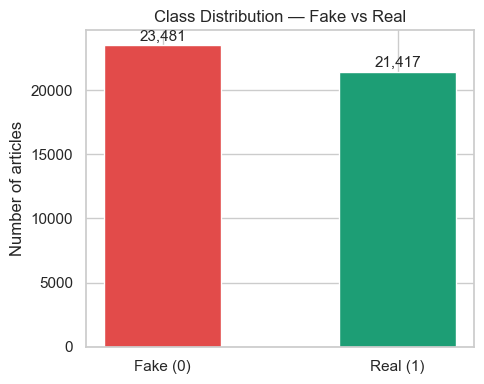

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Fake (0)', 'Real (1)'],
              [stats['fake'], stats['real']],
              color=['#E24B4A', '#1D9E75'], width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 150,
            f"{int(bar.get_height()):,}",
            ha='center', va='bottom', fontsize=11)
ax.set_title('Class Distribution — Fake vs Real')
ax.set_ylabel('Number of articles')
plt.tight_layout()
plt.savefig('../outputs/results/class_distribution.png', dpi=150)
plt.show()

## 2. Article length distribution

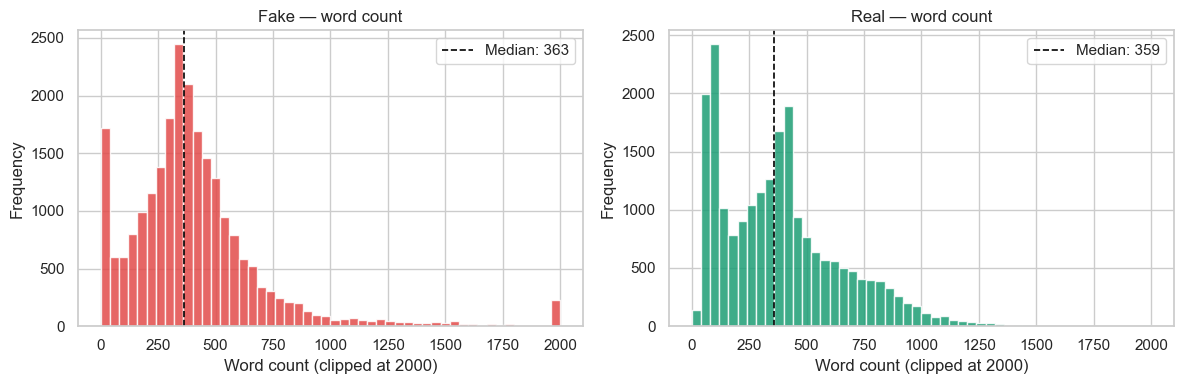

         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0
1      21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0


In [6]:
df['word_count'] = df['text'].apply(lambda t: len(str(t).split()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, name, color) in zip(
        axes, [(0, 'Fake', '#E24B4A'), (1, 'Real', '#1D9E75')]):
    subset = df[df['label'] == label]['word_count']
    ax.hist(subset.clip(upper=2000), bins=50, color=color,
            edgecolor='white', alpha=0.85)
    ax.axvline(subset.median(), color='black', linestyle='--',
               linewidth=1.2, label=f'Median: {int(subset.median())}')
    ax.set_title(f'{name} — word count')
    ax.set_xlabel('Word count (clipped at 2000)')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/results/length_distribution.png', dpi=150)
plt.show()
print(df.groupby('label')['word_count'].describe())

## 3. Top words per class (stopwords removed)

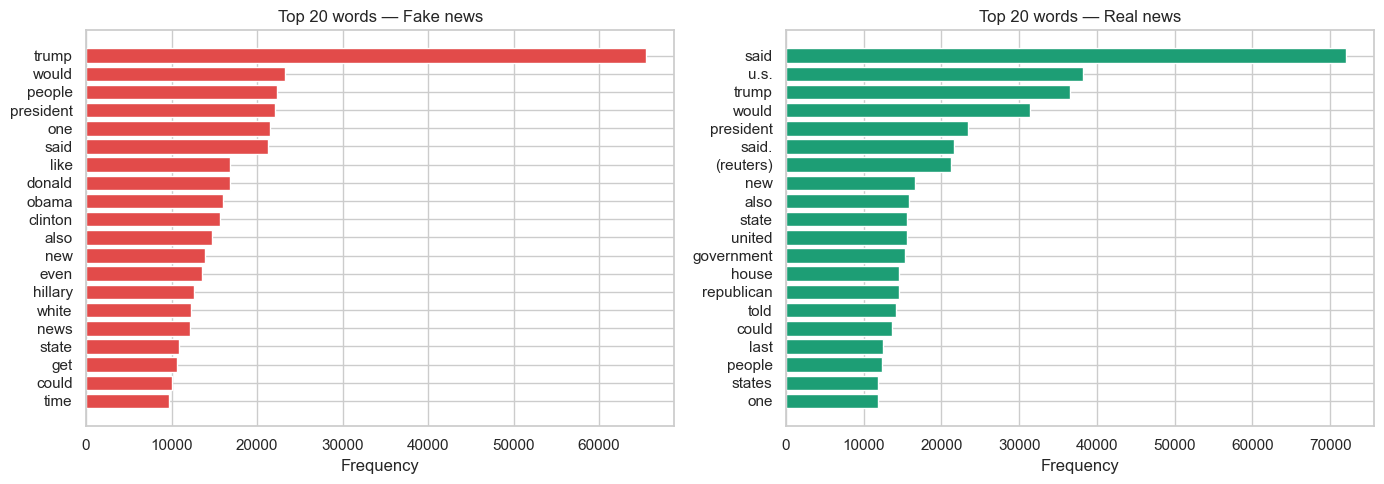

In [7]:
def top_words(text_series, n=20):
    all_words = []
    for doc in text_series:
        tokens = str(doc).lower().split()
        all_words.extend([w for w in tokens
                          if w not in STOP_WORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

fake_top = top_words(df[df['label'] == 0]['text'])
real_top = top_words(df[df['label'] == 1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, name, color in zip(
        axes,
        [fake_top, real_top],
        ['Fake', 'Real'],
        ['#E24B4A', '#1D9E75']):
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=color, edgecolor='white')
    ax.set_title(f'Top 20 words — {name} news')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/results/top_words.png', dpi=150)
plt.show()

## 4. Subject category breakdown

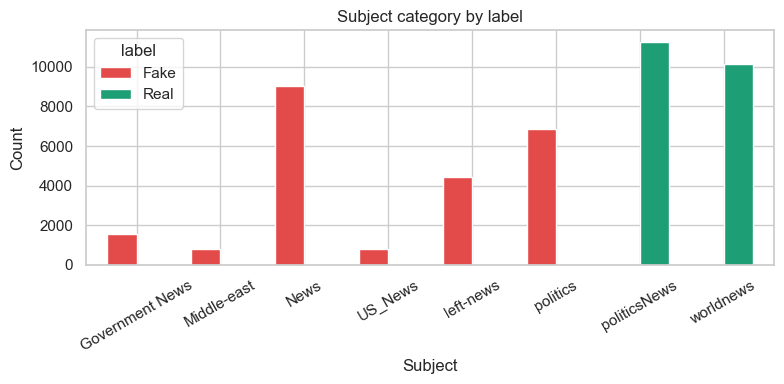

In [8]:
if 'subject' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    subject_counts = (
        df.groupby(['subject', 'label'])
        .size().unstack(fill_value=0)
        .rename(columns={0: 'Fake', 1: 'Real'})
    )
    subject_counts.plot(kind='bar', ax=ax,
                        color=['#E24B4A', '#1D9E75'],
                        edgecolor='white', width=0.7)
    ax.set_title('Subject category by label')
    ax.set_xlabel('Subject')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../outputs/results/subject_distribution.png', dpi=150)
    plt.show()